# Generate Performance Boxplots and Feature Importance Calculations from WandB Runs
This notebook is designed to analyze performance metrics and feature importance from WandB runs. It includes sections for importing libraries, fetching data, generating performance boxplots, and calculating feature importance.

This notebook is essentially a pared-down, cleaned-up version of `stability_and_performance_analysis.ipynb`.

## Import Required Libraries
Import necessary libraries such as `wandb`, `pandas`, `numpy`, `matplotlib`, and `seaborn`.

In [117]:
# Import Required Libraries
import logging
import os
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import wandb

# Setup Logging and Configuration
logging.basicConfig(
    format="%(asctime)s %(levelname)-8s [%(name)s] %(message)s",
    level=logging.INFO,
    datefmt="%Y-%m-%d %H:%M:%S",
    force=True,
)
logger = logging.getLogger(__name__)

## Setup Logging and Configuration
Set up logging and define configurations such as WandB project name, sweep ID, and directories for saving results.

In [128]:
# Define WandB project and sweep details
PROJECT_NAME = "millergw/prostate_met_status"

GROUP_IDs = [
    # "simulated_data_001", # DO NOT USE; we used the test data during training as an evaluation set
    "simulated_data_002", # (n_samples = 10k, 1 seed, continuous)
    "simulated_data_003", #(n_samples = 1k, 3 seeds, binary and continuous)
    "simulated_data_004", # (n_samples = 10k, 2 seeds, continuous)
    "simulated_data_005", # (n_samples = 10k, binary, 3 seeds)
             ]

# # Define directories for saving results
FIGDIR = f"../figures/joint_simulation_results/"
RESULTS_DIR = f"../results/joint_simulation_results/"
# make directory if it doesn't exist
os.makedirs(os.path.join(FIGDIR), exist_ok=True)

# Figure parameters
figsize_tuple = (2.4, 2.1)
aspect_ratio_value = 0.5
cmap_style = "viridis"

## Fetch WandB Runs and Performance Metrics (grouped by model_type, OR, and sigma)
Use the WandB API to fetch runs and extract performance metrics grouped by `model_type`, `odds_ratio`, `sigma`, and `n_samples` for purposes of assessing the 'power curve' of the model. Store the results in a DataFrame.

In [129]:
# Initialize W&B API
api = wandb.Api()
# Collect runs from both sweeps
all_records = []
for group_id in GROUP_IDs: 
    runs = api.runs(f"{PROJECT_NAME}", filters={"group": group_id, "state": "finished"})
    for run in runs: 
        config = run.config
        summary = run.summary
        all_records.append({
            "run_id": run.id,
            "run_name": run.name,
            "model_type": config.get("model_type"),
            "sample_binary": config.get("sample_binary"),
            "n_samples": config.get("num_samples"),
            "datasets": config.get("datasets"),
            "sigma": float(config.get("sigma")),
            "odds_ratio": float(config.get("odds_ratio")),
            "save_dir": config.get("save_dir"),
            "num_class1_samples": config.get("num_class1_samples"),
            "num_class0_samples": config.get("num_class0_samples"),
            "deltaMuGenes": config.get("deltaMuGenes"),
            "mod0_genes": config.get("mod0_genes"),
            "mod1_genes": config.get("mod1_genes"),
        })
        for split in ["train", "validation", "test"]:
            all_records[-1][f"{split}_roc_auc_score"] = summary.get(f"{split}_roc_auc_score")
            all_records[-1][f"{split}_balanced_acc"] = summary.get(f"{split}_balanced_acc")
            all_records[-1][f"{split}_avg_precision"] = summary.get(f"{split}_average_precision_score")
        for split in ["validation", "test"]:
            all_records[-1][f"{split}_feature_importances_path"] = os.path.join(config.get("save_dir"), f"{split}_gene_feature_importances.csv")
            all_records[-1][f"{split}_gene_importances_path"] = os.path.join(config.get("save_dir"), f"{split}_gene_importances.csv")

# Convert to a single DataFrame
df = pd.DataFrame(all_records)

# Add a counts column for each group
group_cols = ["model_type", "n_samples", "odds_ratio", "sigma", "sample_binary"]
df_counts = df.groupby(group_cols).size().reset_index(name="count")

# filter to only model_type == "pnet"
df = df[df["model_type"] == "pnet"].reset_index(drop=True)

# in "save_dir" column, replace "../../results/" with "/mnt/disks/gmiller_data1/pnet/results"
df["save_dir"] = df["save_dir"].str.replace("../../results/", "/mnt/disks/gmiller_data1/pnet/results/", regex=False)

# eval_set = "test"
# df["feature_importances_path"] = df.apply(lambda row: os.path.join(row["save_dir"], f"{eval_set}_gene_feature_importances.csv"), axis=1)
# df["gene_importances_path"] = df.apply(lambda row: os.path.join(row["save_dir"], f"{eval_set}_gene_importances.csv"), axis=1)

# Add a unique group identifer column by joining together the unique identifiers: ["model_type", "n_features", "odds_ratio", "control_frequency", "sample_binary"]
df["group_identifier"] = df.apply(
    lambda row: f"OR-{row['odds_ratio']}_sigma-{row['sigma']}_nSamples-{row['n_samples']}_sampleBinary-{row['sample_binary']}",
    axis=1)

# Average over seeds
df_avg = df.groupby(group_cols, as_index=False).mean()

# Merge counts into df_avg
df_avg = df_avg.merge(df_counts, on=group_cols)

In [130]:
df.shape

(192, 28)

In [131]:
df_avg

,model_type,n_samples,odds_ratio,sigma,sample_binary,num_class1_samples,num_class0_samples,train_roc_auc_score,train_balanced_acc,train_avg_precision,validation_roc_auc_score,validation_balanced_acc,validation_avg_precision,test_roc_auc_score,test_balanced_acc,test_avg_precision,count
0,pnet,1000,1.0,0.0,False,500.0,500.0,0.532193,0.522381,0.529872,0.484415,0.508889,0.501781,0.494933,0.486667,0.523121,3
1,pnet,1000,1.0,0.0,True,500.0,500.0,0.500476,0.500000,0.500238,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,3
2,pnet,1000,1.0,0.1,False,500.0,500.0,0.485580,0.498571,0.497272,0.490844,0.502222,0.519574,0.481600,0.497778,0.507084,3
3,pnet,1000,1.0,0.1,True,500.0,500.0,0.500000,0.500000,0.500238,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,3
4,pnet,1000,1.0,0.5,False,500.0,500.0,0.604423,0.542857,0.588490,0.554133,0.537778,0.551720,0.487704,0.504444,0.514062,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,pnet,10000,10.0,0.1,True,5000.0,5000.0,1.000000,0.999810,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3
60,pnet,10000,10.0,0.5,False,5000.0,5000.0,0.999241,0.986571,0.999284,0.998674,0.988222,0.998929,0.999074,0.988000,0.999175,3
61,pnet,10000,10.0,0.5,True,5000.0,5000.0,1.000000,0.999857,1.000000,1.000000,0.999778,1.000000,1.000000,0.999333,1.000000,3
62,pnet,10000,10.0,0.8,False,5000.0,5000.0,0.999544,0.988476,0.999560,0.999723,0.991333,0.999728,0.999121,0.986000,0.999168,3


## helper functions

In [132]:
def smart_ticklabels(labels):
    return [f"{int(l)}" if float(l).is_integer() else f"{l:.1f}" for l in labels]

def get_smart_odds_ratio_labels(axessubplot_object):
    """Expects type <class 'matplotlib.axes._subplots.AxesSubplot'> as input"""
    smart_yticks = smart_ticklabels([float(l.get_text()) for l in axessubplot_object.get_yticklabels()])
    return smart_yticks


In [133]:
# eval_set = "test"  # Set the evaluation set to 'test' for all runs

# # Function to draw heatmap for each evaluation set (runs on simulation_data_002; duplicate indices if try to include others)
# def draw_heatmap(data, **kwargs):
#     pivoted = data.pivot(index="odds_ratio", columns="sigma", values=f"{eval_set}_avg_precision")
#     sns.heatmap(pivoted, cmap=cmap_style, annot=True, fmt=".2f", cbar=False, **kwargs)

# for eval_set in ["train", "validation", "test"]:
#     g = sns.FacetGrid(
#     df_avg,
#     row="n_samples", # change this to sample_binary?
#     col="model_type",
#     margin_titles=True,
#     height=2,
#     aspect=1
# )
#     g.map_dataframe(draw_heatmap)
#     g.set_titles(row_template="n_samples = {row_name}", col_template="{col_name}")
#     g.set_axis_labels("sigma", "odds_ratio")
#     g.figure.subplots_adjust(top=0.85)
#     # g.figure.suptitle("Mean Average Precision (N=1) when data sampled from joint distribution", fontsize=14)
#     g.figure.suptitle(f"Joint, continuous, N=10k ({eval_set} set)", fontsize=14)
#     plt.show()


## 3 different results/subresults
Here we make performance heatmaps for three different subsets of the data:

- (A) sample_binary = True, n_samples=1000
- (B) sample_binary = False, n_samples=1000
- (C) sample_binary = False, n_samples=10000

Plot these side-by-side in one figure: "Mean Average Precision under varied joint sampling strategies"

In [134]:
# eval_set = "test"  # Set the evaluation set to 'test' for all runs
# # (A) sample_binary = True, n_samples = 1000
# df_A = df_avg[(df_avg["sample_binary"] == True) & (df_avg["n_samples"] == 1000)]
# fig, ax = plt.subplots(figsize=figsize_tuple)
# sns.heatmap(
#     df_A.pivot(index="odds_ratio", columns="sigma", values=f"{eval_set}_avg_precision"),
#     cmap=cmap_style, annot=True, fmt=".2f", cbar=False,
# )
# ax.set_aspect(aspect_ratio_value, adjustable='box')
# plt.title(f"(A) Binary, N=1k ({eval_set} set)")
# plt.xlabel("sigma")
# plt.ylabel("odds_ratio")
# plt.show()

# # (B) sample_binary = False, n_samples = 1000
# df_B = df_avg[(df_avg["sample_binary"] == False) & (df_avg["n_samples"] == 1000)]
# fig, ax = plt.subplots(figsize=figsize_tuple)
# sns.heatmap(
#     df_B.pivot(index="odds_ratio", columns="sigma", values=f"{eval_set}_avg_precision"),
#     cmap=cmap_style, annot=True, fmt=".2f", cbar=False,
# )
# ax.set_aspect(aspect_ratio_value, adjustable='box')
# plt.title(f"(B) Continuous, N=1k ({eval_set} set)")
# plt.xlabel("sigma")
# plt.ylabel("odds_ratio")
# plt.show()

# # (C) sample_binary = False, n_samples = 10000
# df_C = df_avg[(df_avg["sample_binary"] == True) & (df_avg["n_samples"] == 10000)]
# fig, ax = plt.subplots(figsize=figsize_tuple)
# sns.heatmap(
#     df_C.pivot(index="odds_ratio", columns="sigma", values=f"{eval_set}_avg_precision"),
#     cmap=cmap_style, annot=True, fmt=".2f", cbar=False,
# )
# ax.set_aspect(aspect_ratio_value, adjustable='box')
# plt.title(f"(C) Continuous, N=10k ({eval_set} set)")
# plt.xlabel("sigma")
# plt.ylabel("odds_ratio")
# plt.show()

# # (D) sample_binary = False, n_samples = 10000
# df_D = df_avg[(df_avg["sample_binary"] == False) & (df_avg["n_samples"] == 10000)]
# fig, ax = plt.subplots(figsize=figsize_tuple)
# sns.heatmap(
#     df_D.pivot(index="odds_ratio", columns="sigma", values=f"{eval_set}_avg_precision"),
#     cmap=cmap_style, annot=True, fmt=".2f", cbar=False,
# )
# ax.set_aspect(aspect_ratio_value, adjustable='box')
# plt.title(f"(D) Continuous, N=10k ({eval_set} set)")
# plt.xlabel("sigma")
# plt.ylabel("odds_ratio")
# plt.show()

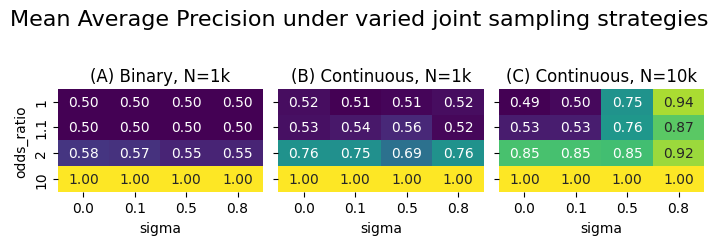

In [135]:
fig, axes = plt.subplots(1, 3, figsize=(figsize_tuple[0]*3, figsize_tuple[1]), sharey=True)
# (A) sample_binary = True, n_samples = 1000
df_A = df_avg[(df_avg["sample_binary"] == True) & (df_avg["n_samples"] == 1000)]
sns.heatmap(
    df_A.pivot(index="odds_ratio", columns="sigma", values=f"{eval_set}_avg_precision"),
    cmap=cmap_style, annot=True, fmt=".2f", ax=axes[0], cbar=False
)
axes[0].set_aspect(aspect_ratio_value)
axes[0].set_title("(A) Binary, N=1k")
axes[0].set_xlabel("sigma")
axes[0].set_ylabel("odds_ratio")

# (B) sample_binary = False, n_samples = 1000
df_B = df_avg[(df_avg["sample_binary"] == False) & (df_avg["n_samples"] == 1000)]
sns.heatmap(
    df_B.pivot(index="odds_ratio", columns="sigma", values=f"{eval_set}_avg_precision"),
    cmap=cmap_style, annot=True, fmt=".2f", ax=axes[1], cbar=False
)
axes[1].set_aspect(aspect_ratio_value)
axes[1].set_title("(B) Continuous, N=1k")
axes[1].set_xlabel("sigma")
axes[1].set_ylabel("")

# (C) sample_binary = False, n_samples = 10000
df_C = df_avg[(df_avg["sample_binary"] == False) & (df_avg["n_samples"] == 10000)]
sns.heatmap(
    df_C.pivot(index="odds_ratio", columns="sigma", values=f"{eval_set}_avg_precision"),
    cmap=cmap_style, annot=True, fmt=".2f", ax=axes[2], cbar=False
)
axes[2].set_aspect(aspect_ratio_value)
axes[2].set_title("(C) Continuous, N=10k")
axes[2].set_xlabel("sigma")
axes[2].set_ylabel("")

axes[0].set_yticklabels(get_smart_odds_ratio_labels(axes[0]))

fig.suptitle("Mean Average Precision under varied joint sampling strategies", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

In [136]:
# ## I like this code! Feels more modular and readable.
# def heatmap_with_counts(df, title):
#     precision = df.pivot(index="odds_ratio", columns="sigma", values=f"{eval_set}_avg_precision")
#     counts = df.pivot(index="odds_ratio", columns="sigma", values="count")
    
#     # Create string annotations
#     annot = precision.copy()
#     annot = annot.applymap(str)  # Convert precision to string first
#     for r in precision.index:
#         for c in precision.columns:
#             p = precision.loc[r, c]
#             n = counts.loc[r, c]
#             if pd.notnull(p) and pd.notnull(n):
#                 annot.loc[r, c] = f"{p:.2f}\n(n={int(n)})"
#             else:
#                 annot.loc[r, c] = ""

#     plt.figure(figsize=(4, 4))
#     sns.heatmap(precision, cmap=cmap_style, annot=annot, fmt="", cbar=False)
#     plt.title(title)
#     plt.xlabel("sigma")
#     plt.ylabel("odds_ratio")
#     plt.tight_layout()
#     plt.show()


# eval_set = "test"
# heatmap_with_counts(
#     df_avg[(df_avg["sample_binary"] == True) & (df_avg["n_samples"] == 1000)],
#     f"Binary, N=1k ({eval_set} set)"
# )

# heatmap_with_counts(
#     df_avg[(df_avg["sample_binary"] == False) & (df_avg["n_samples"] == 1000)],
#     f"Continuous, N=1k ({eval_set} set)"
# )

# heatmap_with_counts(
#     df_avg[(df_avg["sample_binary"] == True) & (df_avg["n_samples"] == 10000)],
#     f"Binary, N=10k ({eval_set} set)"
# )

# heatmap_with_counts(
#     df_avg[(df_avg["sample_binary"] == False) & (df_avg["n_samples"] == 10000)],
#     f"Continuous, N=10k ({eval_set} set)"
# )


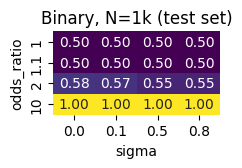

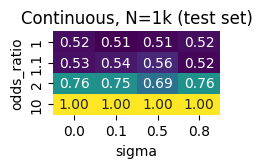

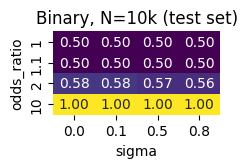

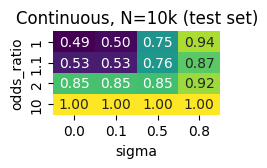

In [138]:
# each plotted as separate heatmap
def heatmap_no_counts(df, title):
    precision = df.pivot(index="odds_ratio", columns="sigma", values=f"{eval_set}_avg_precision")
    # plt.figure(figsize=figsize_tuple)
    fig, ax = plt.subplots(figsize=figsize_tuple)
    sns.heatmap(precision, cmap=cmap_style, annot=True, fmt=".2f", cbar=False)
    ax.set_aspect(aspect_ratio_value, adjustable='box')
    ax.set_yticklabels(get_smart_odds_ratio_labels(ax))

    plt.title(title)
    plt.xlabel("sigma")
    plt.ylabel("odds_ratio")
    plt.tight_layout()
    plt.show()

# fig, ax = plt.subplots(figsize=figsize_tuple)
# sns.heatmap(
#     df_A.pivot(index="odds_ratio", columns="sigma", values=f"{eval_set}_avg_precision"),
#     cmap=cmap_style, annot=True, fmt=".2f", cbar=False,
# )
# ax.set_aspect(aspect_ratio_value, adjustable='box')

eval_set = "test"
heatmap_no_counts(
    df_avg[(df_avg["sample_binary"] == True) & (df_avg["n_samples"] == 1000)],
    f"Binary, N=1k ({eval_set} set)"
)

heatmap_no_counts(
    df_avg[(df_avg["sample_binary"] == False) & (df_avg["n_samples"] == 1000)],
    f"Continuous, N=1k ({eval_set} set)"
)

heatmap_no_counts(
    df_avg[(df_avg["sample_binary"] == True) & (df_avg["n_samples"] == 10000)],
    f"Binary, N=10k ({eval_set} set)"
)

heatmap_no_counts(
    df_avg[(df_avg["sample_binary"] == False) & (df_avg["n_samples"] == 10000)],
    f"Continuous, N=10k ({eval_set} set)"
)

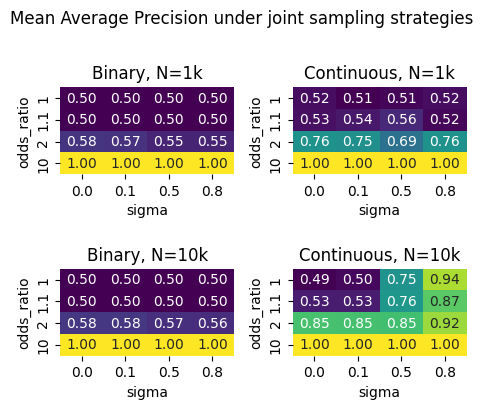

In [166]:
# one 2x2 heatmap
eval_set = "test"
fig, axes = plt.subplots(2, 2, figsize=(figsize_tuple[0]*2, figsize_tuple[1]*2))
def heatmap_no_counts(df, title, ax):
    precision = df.pivot(index="odds_ratio", columns="sigma", values=f"{eval_set}_avg_precision")
    sns.heatmap(
        precision, cmap=cmap_style, annot=True, fmt=".2f",
        cbar=False, ax=ax
    )
    ax.set_aspect(aspect_ratio_value, adjustable='box')
    ax.set_yticklabels(get_smart_odds_ratio_labels(ax))
    ax.set_title(title)
    ax.set_xlabel("sigma")
    ax.set_ylabel("odds_ratio")


# Row 0: N = 1k
heatmap_no_counts(
    df_avg[(df_avg["sample_binary"] == True) & (df_avg["n_samples"] == 1000)],
    "Binary, N=1k",
    ax=axes[0, 0]
)

heatmap_no_counts(
    df_avg[(df_avg["sample_binary"] == False) & (df_avg["n_samples"] == 1000)],
    "Continuous, N=1k",
    ax=axes[0, 1]
)

# Row 1: N = 10k
heatmap_no_counts(
    df_avg[(df_avg["sample_binary"] == True) & (df_avg["n_samples"] == 10000)],
    "Binary, N=10k",
    ax=axes[1, 0]
)

heatmap_no_counts(
    df_avg[(df_avg["sample_binary"] == False) & (df_avg["n_samples"] == 10000)],
    "Continuous, N=10k",
    ax=axes[1, 1]
)

fig.suptitle("Mean Average Precision under joint sampling strategies")
plt.tight_layout()
plt.show()


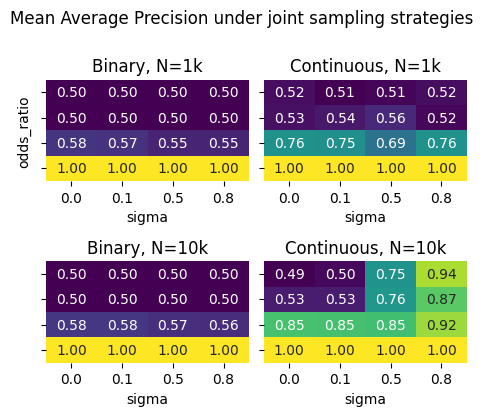

In [167]:
fig, axes = plt.subplots(2, 2, figsize=(figsize_tuple[0]*2, figsize_tuple[1]*2), sharey=True)
# (A) sample_binary = True, n_samples = 1000
df_A = df_avg[(df_avg["sample_binary"] == True) & (df_avg["n_samples"] == 1000)]
sns.heatmap(
    df_A.pivot(index="odds_ratio", columns="sigma", values=f"{eval_set}_avg_precision"),
    cmap=cmap_style, annot=True, fmt=".2f", ax=axes[0,0], cbar=False
)
axes[0,0].set_aspect(aspect_ratio_value)
axes[0,0].set_title("Binary, N=1k")
axes[0,0].set_xlabel("sigma")
axes[0,0].set_ylabel("odds_ratio")

# (B) sample_binary = False, n_samples = 1000
df_B = df_avg[(df_avg["sample_binary"] == False) & (df_avg["n_samples"] == 1000)]
sns.heatmap(
    df_B.pivot(index="odds_ratio", columns="sigma", values=f"{eval_set}_avg_precision"),
    cmap=cmap_style, annot=True, fmt=".2f", ax=axes[0,1], cbar=False
)
axes[0,1].set_aspect(aspect_ratio_value)
axes[0,1].set_title("Continuous, N=1k")
axes[0,1].set_xlabel("sigma")
axes[0,1].set_ylabel("")

df_B10 = df_avg[(df_avg["sample_binary"] == True) & (df_avg["n_samples"] == 10000)]
sns.heatmap(
    df_B10.pivot(index="odds_ratio", columns="sigma", values=f"{eval_set}_avg_precision"),
    cmap=cmap_style, annot=True, fmt=".2f", ax=axes[1,0], cbar=False
)
axes[1,0].set_aspect(aspect_ratio_value)
axes[1,0].set_title("Binary, N=10k")
axes[1,0].set_xlabel("sigma")
axes[1,0].set_ylabel("")

axes[1,0].set_yticklabels(get_smart_odds_ratio_labels(axes[1,0]))

# (C) sample_binary = False, n_samples = 10000
df_C = df_avg[(df_avg["sample_binary"] == False) & (df_avg["n_samples"] == 10000)]
sns.heatmap(
    df_C.pivot(index="odds_ratio", columns="sigma", values=f"{eval_set}_avg_precision"),
    cmap=cmap_style, annot=True, fmt=".2f", ax=axes[1,1], cbar=False
)
axes[1,1].set_aspect(aspect_ratio_value)
axes[1,1].set_title("Continuous, N=10k")
axes[1,1].set_xlabel("sigma")
axes[1,1].set_ylabel("")

axes[1,1].set_yticklabels(get_smart_odds_ratio_labels(axes[1,1]))

fig.suptitle("Mean Average Precision under joint sampling strategies")
plt.tight_layout()
plt.show()

## scratch: WIP get feat imps

Goal: heatmap-style plot with the mean/median rank (importance) of the:

- deltaMu genes
- genes only in corr module
- genes in both corr module that also have deltaMu

In [27]:
def load_feature_importances(importances_path):
    """
    Load feature importance data from a CSV file.

    Args:
        importances_path (str): Path to the feature importance file.

    Returns:
        pd.DataFrame: DataFrame of feature importances.
    """
    if not os.path.exists(importances_path):
        raise FileNotFoundError(f"File not found: {importances_path}")
    logger.debug(f"Loading feature importances from {importances_path}")
    return pd.read_csv(importances_path).set_index('Unnamed: 0')


def process_importances(imps, response_df):
    """
    Process feature importances by joining with response data and calculating differences between sample classes.
    This function computes the mean feature importances for each response class and then calculates the difference between them.
    The result is a Series of feature importance differences.

    Args:
        imps (pd.DataFrame): Feature importance DataFrame.
        response_df (pd.DataFrame): Response variable DataFrame.

    Returns:
        pd.Series: Processed feature importance differences.
    """
    logger.debug(f"head of imps.join(response_df).groupby('response').mean(): {imps.join(response_df).groupby('response').mean().head()}")
    logger.debug(f"shape of imps.join(response_df).groupby('response').mean(): {imps.join(response_df).groupby('response').mean().shape}")
    return imps.join(response_df).groupby('response').mean().diff(axis=0).iloc[1]

def load_response_variable(response_path):
    response_df = pd.read_csv(response_path).set_index('Tumor_Sample_Barcode')
    # rename the column to 'response' for consistency
    response_df.rename(columns={"is_met": "response"}, inplace=True)
    return response_df

def process_feature_importances(df, response_df=None, response_df_path_column='target_f', importance_path_column='feature_importances_path', group_identifier_column='group_identifier'):
    """
    Process feature importance data for multiple runs and group by dataset.

    Args:
        df (pd.DataFrame): DataFrame with feature importance paths and dataset info.
        response_df (pd.DataFrame): Response variable DataFrame.

    Returns:
        tuple: Dictionaries of DataFrames for feature importances and ranks grouped by the input datasets used in the model.
    """
    imps_by_key = {}
    ranks_by_key = {}

    for _, row in df.iterrows():
        try:
            if response_df is None:
                # Load the response variable DataFrame from the specified path
                response_df = load_response_variable(row[response_df_path_column])
            # Load feature importances from the specified path
            imps = load_feature_importances(row[importance_path_column])
            processed_imps = process_importances(imps, response_df)
            logger.debug(f"processed_imps.head(): {imps.head()}")
            logger.debug(f"processed_imps.shape: {imps.shape}")
            ranks = processed_imps.abs().rank(ascending=False)

            key = row[group_identifier_column]
            imps_by_key.setdefault(key, []).append(processed_imps)
            ranks_by_key.setdefault(key, []).append(ranks)
        except FileNotFoundError as e:
            print(e)
            continue

    df_imps_by_key = {key: pd.DataFrame(imps_list) for key, imps_list in imps_by_key.items()}
    df_ranks_by_key = {key: pd.DataFrame(ranks_list) for key, ranks_list in ranks_by_key.items()}
    return df_imps_by_key, df_ranks_by_key



def extract_top_features_from_df(df_per_dataset, top_n=10, keep_smallest_n=True, index_label=None):
    """
    Extract the top N features by rank for each dataset.

    Args:
        df_per_dataset (dict): Dictionary containing feature-level pd DataFrames for each dataset.
        top_n (int): Number of top features to extract.
        keep_smallest_n (bool): Whether to sort in ascending order (lower rank is better).

    Returns:
        pd.DataFrame: DataFrame containing the top N features for each dataset.
    """
    top_features_df = pd.DataFrame()

    # Iterate over the dictionary to calculate top features
    for dataset, df in df_per_dataset.items():
        # Calculate the mean rank for each feature and select the top N
        top_features = df.mean(axis=0).sort_values(ascending=keep_smallest_n)[:top_n]
        # Add the top features as a column to the DataFrame
        top_features_df[dataset] = top_features.index

    # Set the index of the DataFrame to be 1 through top_n
    top_features_df.index = range(1, top_n + 1)

    if index_label is not None:
        top_features_df.index.name = index_label

    return top_features_df


In [28]:
# building response variable DataFrame from scratch
n1 = n0 = 500
y = np.concatenate([np.ones(n1), np.zeros(n0)])
y = pd.DataFrame(y.astype(int), index=[f"Sample_{i}" for i in range(n1+n0)], columns=["response"])
y

,response
Sample_0,1
Sample_1,1
Sample_2,1
Sample_3,1
Sample_4,1
...,...
Sample_995,0
Sample_996,0
Sample_997,0
Sample_998,0


In [29]:
# gene x modality
# df_imps_by_key, df_ranks_by_key = process_feature_importances(df, importance_path_column=f'{eval_set}_feature_importances_path'), response_df=y)

# gene
df_imps_by_key, df_ranks_by_key = process_feature_importances(df, importance_path_column=f'{eval_set}_gene_importances_path', response_df=y)

In [30]:
df_ranks_by_key["OR-1.0_sigma-0.0_nSamples-10000_sampleBinary-False"].head()

,TMEM71,VWC2,GRIA2,TOMM40L,ZNF445,B3GALT1,CROCC,DPY19L4,MRPL44,OR51M1,...,ZNF248,RUSC1,NCOA1,RIOK1,SAMD12,GRID2,SGCZ,ARHGAP1,GCNT4,FNIP1
1.0,28.0,22.0,95.0,5.0,40.0,31.0,79.0,77.0,58.0,36.0,...,39.0,56.0,1.0,29.0,70.0,13.0,90.0,23.0,64.0,85.0
1.0,91.0,61.0,85.0,65.0,57.0,83.0,27.0,23.0,66.0,80.0,...,53.0,34.0,52.0,56.0,78.0,60.0,25.0,74.0,79.0,88.0
1.0,81.0,76.0,73.0,88.0,22.0,11.0,91.0,79.0,2.0,72.0,...,52.0,19.0,27.0,30.0,29.0,17.0,65.0,90.0,44.0,57.0


## Get run-level rank and importance information for all the relevant gene sets
Each row in df_feature_importance_paths corresponds to a run. I would like my final output to be a DF with columns [run_id, gene_set, gene, rank, imp]. The run_id is the identifer for a given run (wandb run id). The gene set is one of "deltaMuGenes", "mod1_genes", "mod0_genes". The rank is the mean rank of the gene across all samples in that run. The imp is the mean importance of the gene across all samples in that run.

I have some code to get the importance DF (imps) and rank DF (ranks) for a given run.

```
for _, row in df_feature_importance_paths.iterrows():
try:
    if response_df is None:
        # Load the response variable DataFrame from the specified path
        response_df = load_response_variable(row[response_df_path_column])
    # Load feature importances from the specified path
    imps = load_feature_importances(row[importance_path_column])
    processed_imps = process_importances(imps, response_df)
    ranks = processed_imps.abs().rank(ascending=False)
```
These DFs are samples x genes. Collapse this to the average importance by calculating the mean for each gene. Restrict to genes that are in one of the three gene_sets. 

With this information, I want you to implement code to build my final DF as I described.

In [31]:
def build_runwise_gene_importance_rank_df(df, response_df, importance_path_column='gene_importances_path'):
    """
    Build a DataFrame summarizing gene importance and rank for each run and gene set.

    For each run in df, this function:
      - Loads the gene importances and computes the class-difference importance vector.
      - Computes the absolute rank of each gene (lower rank = more important).
      - Restricts to genes in each of three sets: "deltaMuGenes", "mod1_genes", "mod0_genes".
      - For each gene in each set, records the run ID, gene set, gene name, mean rank, and mean importance.

    Args:
        df (pd.DataFrame): DataFrame with one row per run, containing columns for run_id, gene sets, and path to gene importances.
        response_df (pd.DataFrame): DataFrame with sample responses, indexed by sample name, with column 'response'.
        importance_path_column (str): Column name in df with the path to the gene importances CSV.

    Returns:
        pd.DataFrame: DataFrame with columns [run_id, gene_perturbation_group, gene, rank, imp], where rank and imp are the mean rank and mean importance for each gene in each run and gene set.
    """
    logger.info(f"For each of the {df.shape[0]} model runs, we are getting gene importance and rank for each gene set")
    records = []
    for idx, row in df.iterrows():
        # Use index as run_id if no explicit run_id column
        run_id = row.get("run_id") or row.get("wandb_run_id") or idx
        logger.debug(f"Processing run {run_id} with row: {row.to_dict()}")

        logger.debug("Parse gene sets")
        deltaMuGenes = set(row["deltaMuGenes"])
        mod1_genes = set(row["mod1_genes"])
        mod0_genes = set(row["mod0_genes"])
        gene_perturbation_groups = {
            "deltaMuGenes": deltaMuGenes,
            "mod1_genes": mod1_genes,
            "mod0_genes": mod0_genes,
        }
        logger.debug(f"genes in both deltaMuGenes and mod1_genes: {deltaMuGenes.intersection(mod1_genes)}")

        logger.debug("Load importances")
        try:
            imps = load_feature_importances(row[importance_path_column])
            processed_imps = process_importances(imps, response_df)
            # processed_imps: pd.Series, index=gene names
            ranks = processed_imps.abs().rank(ascending=False)
        except Exception as e:
            logger.warning(f"Skipping run {run_id} due to error: {e}")
            continue        

        logger.debug("For each gene set, collect mean importance and rank for each gene")
        for gene_perturbation_group_name, gene_perturbation_group in gene_perturbation_groups.items():
            for gene in gene_perturbation_group:
                if gene in processed_imps.index and gene in ranks.index:
                    records.append({
                        "run_id": run_id,
                        "gene_perturbation_group": gene_perturbation_group_name,
                        "gene": gene,
                        "rank": ranks[gene],
                        "imp": processed_imps[gene],
                    })

    final_df = pd.DataFrame(records)
    return final_df

# Example usage:
# final_df = build_runwise_gene_importance_rank_df(df, y)
# final_df.head()

In [32]:
# set loger to debug level to see more detailed logs
logger.setLevel(logging.INFO)
eval_set = "test"
per_run_imps_df = build_runwise_gene_importance_rank_df(df, y, importance_path_column=f'{eval_set}_gene_importances_path')
per_run_imps_df

2025-06-22 23:26:18 INFO     [__main__] For each of the 192 model runs, we are getting gene importance and rank for each gene set


,run_id,gene_perturbation_group,gene,rank,imp
0,l7nuqbqr,deltaMuGenes,VIM,97.0,0.000007
1,l7nuqbqr,deltaMuGenes,EXOG,12.0,0.003095
2,l7nuqbqr,deltaMuGenes,REN,48.0,-0.000792
3,l7nuqbqr,deltaMuGenes,ESYT3,75.0,0.000323
4,l7nuqbqr,deltaMuGenes,GPR6,99.0,-0.000002
...,...,...,...,...,...
11515,q62o65dp,mod0_genes,ZNF445,60.5,0.000000
11516,q62o65dp,mod0_genes,PROSC,60.5,0.000000
11517,q62o65dp,mod0_genes,ARMC9,60.5,0.000000
11518,q62o65dp,mod0_genes,GCNT4,60.5,0.000000


## WIP
switch metric to top-k recovery/top-k accuracy (not median rank). "How many of the true signal genes did my model recover among the top K?"
Also possible to use recall at K (same as accuracy but plotted as a curve for varied K) or Precision at K ("how 'pure' is my top K list?)

In [33]:
def filter_runs(df, sample_binary=False, n_samples=10000, model_type="pnet"):
    """Filter runs for a given sample_binary, n_samples, and model_type."""
    return df[
        (df["sample_binary"] == sample_binary) &
        (df["n_samples"] == n_samples) &
        (df["model_type"] == model_type)
    ].copy()

def get_group_identifier(row):
    """Create a group identifier string for a run."""
    return f"OR-{row['odds_ratio']}_sigma-{row['sigma']}_nSamples-{row['n_samples']}_sampleBinary-{row['sample_binary']}"

def assign_group_identifier(df):
    """Assign group_identifier column to a DataFrame."""
    df = df.copy()
    df["group_identifier"] = df.apply(get_group_identifier, axis=1)
    return df

def get_gene_sets(row):
    """Return dict of gene sets for a run."""
    delta = set(row["deltaMuGenes"])
    mod0 = set(row["mod0_genes"])
    mod1 = set(row["mod1_genes"])
    corr = mod0 | mod1 # set union
    only_deltaMu = delta - corr
    only_corr = corr - delta
    both = delta & corr
    return {
        "only_deltaMu": only_deltaMu,
        "only_corr": only_corr,
        "both": both
    }

def add_gene_set_column(per_run_imps_df, df):
    """Add a 'gene_set_type' column to per_run_imps_df: only_deltaMu, only_corr, both."""
    # Build a mapping from run_id to gene sets
    runid_to_sets = {}
    for _, row in df.iterrows():
        runid_to_sets[row["run_id"]] = get_gene_sets(row)
    # Assign gene_set_type for each row in per_run_imps_df
    def which_set(row):
        sets = runid_to_sets.get(row["run_id"], {})
        for set_name, genes in sets.items():
            if row["gene"] in genes:
                return set_name
        return None
    per_run_imps_df = per_run_imps_df.copy()
    per_run_imps_df["gene_set_type"] = per_run_imps_df.apply(which_set, axis=1)
    return per_run_imps_df

def aggregate_heatmap(per_run_imps_df, df, value_col, gene_set_type):
    """
    Aggregate median value_col (rank or imp) for each group_identifier, odds_ratio, sigma, and gene_set_type.
    Returns a DataFrame with odds_ratio as rows, sigma as columns.
    """
    # Merge group_identifier and odds_ratio/sigma into per_run_imps_df
    meta = df[["run_id", "group_identifier", "odds_ratio", "sigma"]]
    merged = per_run_imps_df.merge(meta, on="run_id")
    # Filter for the gene_set_type
    merged = merged[merged["gene_set_type"] == gene_set_type]
    # Group by group_identifier, odds_ratio, sigma, then aggregate median across genes and runs
    agg = merged.groupby(["odds_ratio", "sigma"])[value_col].median().unstack()
    return agg


def aggregate_topk_recovery(per_run_imps_df, df, gene_set_type):
    """
    For each run, compute the fraction of signal genes (of this gene_set_type) recovered in the top K genes,
    where K = total number of signal genes for that run (across all three sets).
    Returns a DataFrame with odds_ratio as rows, sigma as columns, values are median top-K recovery across runs.
    """
    # Merge group_identifier and odds_ratio/sigma into per_run_imps_df
    meta = df[["run_id", "group_identifier", "odds_ratio", "sigma", "deltaMuGenes", "mod0_genes", "mod1_genes"]]
    merged = per_run_imps_df.merge(meta, on="run_id")
    records = []
    for run_id, group in merged.groupby("run_id"):
        # Get all signal genes for this run
        row = group.iloc[0]
        delta = set(row["deltaMuGenes"])
        mod0 = set(row["mod0_genes"])
        mod1 = set(row["mod1_genes"])
        only_deltaMu = delta - (mod0 | mod1)
        only_corr = (mod0 | mod1) - delta
        both = delta & (mod0 | mod1)
        all_signal_genes = only_deltaMu | only_corr | both
        K = len(all_signal_genes)
        if K == 0:
            continue
        # Get the genes of the current gene_set_type for this run
        if gene_set_type == "only_deltaMu":
            signal_genes = only_deltaMu
        elif gene_set_type == "only_corr":
            signal_genes = only_corr
        elif gene_set_type == "both":
            signal_genes = both
        else:
            continue
        if len(signal_genes) == 0:
            continue
        # Get all genes and their ranks for this run
        run_genes = group[["gene", "rank"]].drop_duplicates().set_index("gene")["rank"]
        # For each gene in the set, check if its rank <= K
        n_in_topk = sum(run_genes.get(gene, K+1) <= K for gene in signal_genes)
        # Compute recovery: fraction of signal genes in top K
        recovery = n_in_topk / len(signal_genes)
        records.append({
            "odds_ratio": row["odds_ratio"],
            "sigma": row["sigma"],
            "topk_recovery": recovery
        })
    # Aggregate by odds_ratio, sigma (median across runs)
    df = pd.DataFrame(records)
    heatmap_df = df.groupby(["odds_ratio", "sigma"])["topk_recovery"].median().unstack()
    return heatmap_df

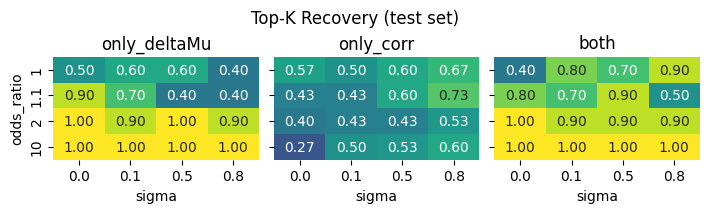

In [ ]:

# --- MAIN LOGIC ---

# 1. Filter runs and per_run_imps_df
df_filt = filter_runs(df, sample_binary=False, n_samples=10000)
run_ids = set(df_filt["run_id"])
per_run_filt = per_run_imps_df[per_run_imps_df["run_id"].isin(run_ids)].copy()

# 2. Assign group_identifier to both DFs
df_filt = assign_group_identifier(df_filt)

# 3. Add gene_set_type column to per_run_filt
per_run_filt = add_gene_set_column(per_run_filt, df_filt)
# drop duplicates in per_run_filt based on run_id, gene, and gene_set_type, because only want to count each gene once per run
per_run_filt = per_run_filt.drop_duplicates(subset=["run_id", "gene", "gene_set_type"])

# 4. Aggregate for each gene set and value type
# gene_sets = ["only_deltaMu", "only_corr", "both"]
# value_types = [("rank", "Median Rank"), ("imp", "Median Importance")]
# fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharey=True)
# for col_idx, gene_set in enumerate(gene_sets):
#     for row_idx, (value_col, title_prefix) in enumerate(value_types):
#         heatmap_df = aggregate_heatmap(per_run_filt, df_filt, value_col, gene_set)
#         ax = axes[row_idx, col_idx]
#         sns.heatmap(heatmap_df, annot=True, cmap=cmap_style, ax=ax, fmt=".2f")
#         ax.set_title(f"{title_prefix}: {gene_set}")
#         ax.set_xlabel("sigma")
#         if col_idx == 0:
#             ax.set_ylabel("odds_ratio")
#         else:
#             ax.set_ylabel("")

# Example usage in your plotting loop:
fig, axes = plt.subplots(1, 3, figsize=(figsize_tuple[0]*3, figsize_tuple[1]), sharey=True)
for col_idx, gene_set in enumerate(["only_deltaMu", "only_corr", "both"]):
    heatmap_df = aggregate_topk_recovery(per_run_filt, df_filt, gene_set)
    ax = axes[col_idx]
    sns.heatmap(heatmap_df, annot=True, cmap=cmap_style, ax=ax, fmt=".2f", vmin=0, vmax=1, cbar=False)
    # ax.set_title(f"Top-K Recovery: {gene_set} ({eval_set} set)")
    ax.set_aspect(aspect_ratio_value)
    ax.set_title(f"{gene_set}")
    ax.set_xlabel("sigma")
    if col_idx == 0:
        ax.set_ylabel("odds_ratio")
    else:
        ax.set_ylabel("")
axes[0].set_yticklabels(get_smart_odds_ratio_labels(axes[0]))
# plt.subplots_adjust(top=0.85, hspace=0.4)
plt.tight_layout()
plt.suptitle(f"Top-K Recovery ({eval_set} set)")
plt.show()


## Logic for generating feature importance and rank heatmaps

1. Filter the relevant runs
- Start by filtering df_feature_importance_paths for the subset you want (e.g., Continuous, N=10k).
- Make this filtering modular so you can easily swap to other subsets (e.g., N=1k).

2. Extract gene sets for each run
- For each row/run, parse the gene lists:
    - deltaMuGenes
    - mod0_genes and mod1_genes (combine for "corr module")
- Compute the three gene sets for each run:
    - deltaMuGenes
    - only in corr module (mod0+mod1 minus deltaMu)
    - intersection (deltaMu ∩ (mod0+mod1))

3. Aggregate gene ranks/importances

- For each run, use the corresponding group_identifier to get the gene importance/rank DataFrame from df_ranks_by_key (or df_imps_by_key).
- For each gene set, extract the ranks/importances for the genes in that set.
- Aggregate (e.g., median) across genes in the set, for each run.

4. Aggregate across runs with the same group_identifier
- For each group_identifier (i.e., each cell in the heatmap), aggregate the median ranks/importances across all runs with that group_identifier.

5. Build heatmap DataFrames
- For each gene set, build a DataFrame with odds_ratio as rows and sigma as columns, values are the top K recovery (alternatives: aggregated median ranks/importances.)

6. Plot heatmaps
- Use the same plotting style as elsewhere in the notebook.